In [23]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns 

In [24]:
#
data = yf.Ticker("AAPL") #creates ticker object for apple stocks everything will be referencing this object
data.info # returns a large dict of general comp info: market cap, sector, P/E ratio, 52-week high/low
data.calendar #returns upcoming events like earnings dates and expected EPS ranges
data.analyst_price_targets #retunrs analyst consensus price targets(low, mean, high, current)
data.quarterly_income_stmt #returns the last few quarters of income statement data: rev, gross profit, net income
data.history(period='1mo') # returns a df of daily OHLCV price data for the past 1 month
data.option_chain(data.options[0]).calls # gets the nearest exp dat from the list of options  and fetches 
# the options chain for the date and reutnrs just the call contracts 


,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency
0,AAPL260513C00205000,2026-05-12 18:52:34+00:00,205.0,88.91,87.45,90.90,1.960007,2.252364,13,2,3.021487,True,REGULAR,USD
1,AAPL260513C00230000,2026-05-12 18:54:22+00:00,230.0,63.88,62.35,65.80,2.400002,3.903711,13,1,2.168950,True,REGULAR,USD
2,AAPL260513C00245000,2026-05-12 18:55:48+00:00,245.0,49.03,47.55,50.25,2.520001,5.421688,28,55,1.479495,True,REGULAR,USD
3,AAPL260513C00250000,2026-05-12 18:52:42+00:00,250.0,44.13,42.35,45.85,0.750000,1.723742,5,1,1.583010,True,REGULAR,USD
4,AAPL260513C00255000,2026-05-12 18:54:09+00:00,255.0,39.11,37.30,40.90,2.450001,6.670299,2,1,1.449222,True,REGULAR,USD
5,AAPL260513C00257500,2026-05-12 18:54:14+00:00,257.5,36.61,34.80,38.40,1.209999,3.410369,2,0,1.374027,True,REGULAR,USD
6,AAPL260513C00260000,2026-05-12 18:51:25+00:00,260.0,34.14,32.40,35.85,2.549999,8.074728,11,6,1.284672,True,REGULAR,USD
7,AAPL260513C00265000,2026-05-12 16:08:12+00:00,265.0,29.26,28.80,30.05,1.260000,4.500001,12,0,0.861818,True,REGULAR,USD
8,AAPL260513C00267500,2026-05-07 14:19:36+00:00,267.5,22.99,25.05,28.45,0.000000,0.000000,1,0,1.085942,True,REGULAR,USD
9,AAPL260513C00270000,2026-05-11 17:27:59+00:00,270.0,24.45,23.70,24.70,2.560001,11.694843,1,51,0.406256,True,REGULAR,USD


## Simple Moving Average (SMA)

The SMA averages the closing price over the past $n$ days with equal weight:

$$\text{SMA}_t = \frac{1}{n} \sum_{i=0}^{n-1} P_{t-i}$$

where $P_t$ is the closing price at time $t$ and $n$ is the window size. The first $n-1$ values are undefined ($\text{NaN}$) since there are not enough prior observations to fill the window.

---

## Exponential Moving Average (EMA)

The EMA applies exponentially decaying weights so that recent prices matter more:

$$\text{EMA}_t = \alpha \cdot P_t + (1 - \alpha) \cdot \text{EMA}_{t-1}$$

where the smoothing factor $\alpha$ is:

$$\alpha = \frac{2}{n + 1}$$

As prices get older, the weight $(1-\alpha)^i$ shrinks toward zero — recent prices dominate. Unlike SMA, EMA produces no $\text{NaN}$ gap at the start since it is computed recursively from the first observation.

---

## Why Calculate SMA and EMA?

**Trend Identification**
- Price above SMA/EMA → uptrend; price below → downtrend
- Smooths out day-to-day noise so the broader direction is clearer

**Signal Generation (Crossovers)**
- When a short-term MA crosses above a long-term MA → *golden cross* (bullish signal)
- When it crosses below → *death cross* (bearish signal)

**ML Feature Engineering**
- Raw price is non-stationary (trends upward over time), which hurts model performance
- SMA and EMA give the model a sense of where price has been trending, capturing momentum without overfitting to raw price levels

**EMA vs SMA**
- EMA reacts faster to recent price changes, making it more useful for short-term prediction
- SMA is smoother and better for identifying long-term trends

In [25]:
#simple moving average (30-days)
history = data.history(period='1y')
history['SMA30'] = history['Close'].rolling(window=30).mean() 
sma_30 = history['Close'].rolling(window=30).mean() 

#exponential moving average (50 days)
history['EMA50'] = history['Close'].ewm(span=50, adjust=False).mean()

print(history[['Close','SMA30','EMA50']])

                                Close       SMA30       EMA50
Date                                                         
2025-05-12 00:00:00-04:00  209.957031         NaN  209.957031
2025-05-13 00:00:00-04:00  212.088593         NaN  210.040622
2025-05-14 00:00:00-04:00  211.490982         NaN  210.097499
2025-05-15 00:00:00-04:00  210.614456         NaN  210.117772
2025-05-16 00:00:00-04:00  210.425201         NaN  210.129828
...                               ...         ...         ...
2026-05-06 00:00:00-04:00  287.245361  264.488985  265.516678
2026-05-07 00:00:00-04:00  287.175415  265.648583  266.366040
2026-05-08 00:00:00-04:00  293.050018  266.995010  267.412471
2026-05-11 00:00:00-04:00  292.679993  268.465310  268.403354
2026-05-12 00:00:00-04:00  294.695007  270.075044  269.434399

[252 rows x 3 columns]


## Lagged Returns

---

A **lagged return** is a time-shifted copy of the returns column. Each lag represents what the return was $n$ days ago:

- **Lag1** — yesterday's return $(t-1)$
- **Lag2** — two days ago $(t-2)$
- **Lag3** — three days ago $(t-3)$

Lags turn a time series prediction problem into a standard regression problem — instead of predicting across time, the model predicts today's return $y$ from a set of past return features $X$.

---

## Models Being Implemented

**Linear Regression (completed)**
Uses the Normal Equation to find the optimal weights for the lagged return features. Serves as the baseline model.

**Random Forest (up next)**
A tree-based model that captures non-linear relationships between features and returns that linear regression cannot.

**XGBoost (up next)**
A gradient boosted tree model that handles complex feature interactions and typically outperforms random forest on tabular data.

---

## Features Being Added

| Feature | Description | Method |
|---------|-------------|--------|
| Lag1, Lag2, Lag3 | Past returns | `.shift(n)` |
| Volatility | Recent price swings | `.rolling(5).std()` |
| Momentum | Short term trend | `.rolling(5).mean()` |
| SMA Ratio | Price vs moving average | `Close / SMA30` |

We are using the normal equation for this Linear Regression implementation, we only have a small to medium sized data set, so no Gradient Descent is needed 

Normal Equation:

$${\theta} = (X^T X)^{-1} X^T y$$



Step 1: $X^T X$

$X$ is an $n \times p$ matrix (rows = observations, cols = features). You can't invert a non-square matrix, so you multiply by its transpose first to get a square $p \times p$ matrix that you can invert.

But it's not just a math trick — $X^T X$ actually captures how much variance and covariance exists across your features.

Step 2: $(X^T X)^{-1}$

Inverting it "undoes" the feature relationships — similar to how dividing by a number undoes multiplication. This is what allows you to isolate $\theta$.

Think of the scalar version: if $y = ax$, then $x = a^{-1}y$. The matrix version is the same idea but for systems of equations.

Step 3: $X^T y$

$X^T y$ projects your target $y$ onto the feature space — it captures how much each feature correlates with the output.

Putting it together

Starting from $y = X\theta$, you can't just divide both sides by $X$ since matrix division doesn't exist. So instead:

$$X^T y = X^T X \theta$$
$$(X^T X)^{-1} X^T y = \theta$$

You multiply both sides by $(X^T X)^{-1}$ to isolate $\theta$ — same as dividing both sides by a number in algebra, just in matrix form.

In [26]:
#Linear Regression 
def linear_regression(X,y):
    x_b = np.c_[np.ones((len(X),1)),X]

    theta = np.linalg.inv(x_b.T @ x_b) @ x_b.T @y

    return theta 

In [27]:
history['Return'] = history['Close'].pct_change()

#each lag shifts the return column down by n days
history['Lag1'] = history['Return'].shift(1) #returns on day t-1
history['Lag2'] = history['Return'].shift(2) #returns on day t-2
history['Lag3'] = history['Return'].shift(3) #returns on day t-3

#volatility - rolling standard deviation of returns
history['Vol_5day'] = history['Return'].rolling(window=5).std()
history['Vol_10day'] = history['Return'].rolling(window=10).std()
history['Vol_15day'] = history['Return'].rolling(window=15).std()
history['Vol_30day'] = history['Return'].rolling(window=30).std()

#momentum - rolling mean of returns
history['Momentum_5days'] = history['Return'].rolling(window=5).mean()
history['Momentum_10days'] = history['Return'].rolling(window=10).mean()
history['Momentum_15days'] = history['Return'].rolling(window=15).mean()
history['Momentum_30days'] = history['Return'].rolling(window=30).mean()


history[['Close', 'Return', 'Lag1', 'Lag2', 'Lag3', 'Vol_5day', 'Momentum_5days']]

,Close,Return,Lag1,Lag2,Lag3,Vol_5day,Momentum_5days
Date,,,,,,,
2025-05-12 00:00:00-04:00,209.957031,NaN,NaN,NaN,NaN,NaN,NaN
2025-05-13 00:00:00-04:00,212.088593,0.010152,NaN,NaN,NaN,NaN,NaN
2025-05-14 00:00:00-04:00,211.490982,-0.002818,0.010152,NaN,NaN,NaN,NaN
2025-05-15 00:00:00-04:00,210.614456,-0.004145,-0.002818,0.010152,NaN,NaN,NaN
2025-05-16 00:00:00-04:00,210.425201,-0.000899,-0.004145,-0.002818,0.010152,NaN,NaN
...,...,...,...,...,...,...,...
2026-05-06 00:00:00-04:00,287.245361,0.011718,0.026551,-0.011816,0.032394,0.017685,0.012643
2026-05-07 00:00:00-04:00,287.175415,-0.000244,0.011718,0.026551,-0.011816,0.018333,0.011721
2026-05-08 00:00:00-04:00,293.050018,0.020456,-0.000244,0.011718,0.026551,0.015531,0.009333


In [28]:
#dropped all rows with NaN
history[['Close', 'Return', 'Lag1', 'Lag2', 'Lag3']].dropna()

,Close,Return,Lag1,Lag2,Lag3
Date,,,,,
2025-05-16 00:00:00-04:00,210.425201,-0.000899,-0.004145,-0.002818,0.010152
2025-05-19 00:00:00-04:00,207.954987,-0.011739,-0.000899,-0.004145,-0.002818
2025-05-20 00:00:00-04:00,206.042587,-0.009196,-0.011739,-0.000899,-0.004145
2025-05-21 00:00:00-04:00,201.291428,-0.023059,-0.009196,-0.011739,-0.000899
2025-05-22 00:00:00-04:00,200.564331,-0.003612,-0.023059,-0.009196,-0.011739
...,...,...,...,...,...
2026-05-06 00:00:00-04:00,287.245361,0.011718,0.026551,-0.011816,0.032394
2026-05-07 00:00:00-04:00,287.175415,-0.000244,0.011718,0.026551,-0.011816
2026-05-08 00:00:00-04:00,293.050018,0.020456,-0.000244,0.011718,0.026551


## Volatility

**Volatility** measures how much returns have been swinging over a recent window of days. It does not measure direction — only the size of the moves.

It is calculated as the **rolling standard deviation** of returns:

$$\text{Vol}_t = \sqrt{\frac{1}{n-1} \sum_{i=0}^{n-1} (R_{t-i} - \bar{R})^2}$$

A higher value means the stock has been making large moves recently (high risk), a lower value means it has been calm.

**Why it helps the model:**
- Volatile periods tend to cluster — big moves are often followed by more big moves
- Giving the model recent volatility helps it adjust its predictions based on the current market regime

**Windows used:** 5-day (short term, reactive) and 30-day (long term, stable). The 5-day line is jagged and reacts quickly to sudden events, while the 30-day line is smoother and reflects the broader volatility environment.

In [29]:
#printing out as grids for sanity check
history[['Vol_5day','Vol_10day','Vol_15day','Vol_30day']]

,Vol_5day,Vol_10day,Vol_15day,Vol_30day
Date,,,,
2025-05-12 00:00:00-04:00,NaN,NaN,NaN,NaN
2025-05-13 00:00:00-04:00,NaN,NaN,NaN,NaN
2025-05-14 00:00:00-04:00,NaN,NaN,NaN,NaN
2025-05-15 00:00:00-04:00,NaN,NaN,NaN,NaN
2025-05-16 00:00:00-04:00,NaN,NaN,NaN,NaN
...,...,...,...,...
2026-05-06 00:00:00-04:00,0.017685,0.015464,0.017430,0.015787
2026-05-07 00:00:00-04:00,0.018333,0.015506,0.016902,0.015811
2026-05-08 00:00:00-04:00,0.015531,0.015364,0.016494,0.016063


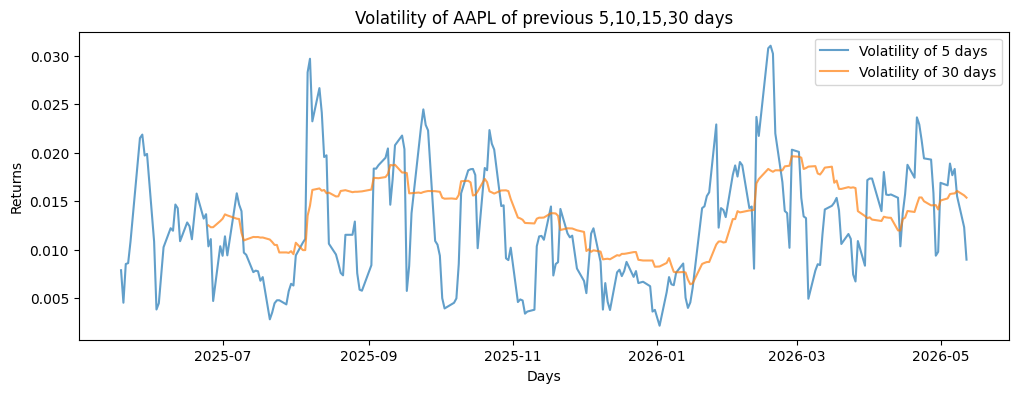

In [30]:
plt.figure(figsize=(12,4))
plt.plot(history['Vol_5day'],label='Volatility of 5 days',alpha=0.7)
plt.plot(history['Vol_30day'],label='Volatility of 30 days',alpha=0.7)
plt.title('Volatility of AAPL of previous 5,10,15,30 days')
plt.xlabel('Days')
plt.ylabel('Returns')
plt.legend()
plt.show()

## Momentum

**Momentum** measures the **direction** of recent returns — whether the stock has been trending up or down over a window of days. Unlike volatility it does care about direction, not just magnitude.

It is calculated as the **rolling mean** of returns:

$$\text{Momentum}_t = \frac{1}{n} \sum_{i=0}^{n-1} R_{t-i}$$

- **Positive momentum** → stock has been going up on average recently
- **Negative momentum** → stock has been trending down
- **Near zero** → no clear direction

**Why it helps the model:**
- Stocks that have been rising tend to keep rising in the short term (momentum effect)
- Gives the model a sense of the current trend direction, complementing the volatility feature which only captures the size of moves

**Windows used:** 5-day, 10-day, 15-day, and 30-day. Shorter windows react faster to recent changes, longer windows reflect the broader trend.

In [31]:
history[['Momentum_5days','Momentum_10days','Momentum_15days','Momentum_30days']]

,Momentum_5days,Momentum_10days,Momentum_15days,Momentum_30days
Date,,,,
2025-05-12 00:00:00-04:00,NaN,NaN,NaN,NaN
2025-05-13 00:00:00-04:00,NaN,NaN,NaN,NaN
2025-05-14 00:00:00-04:00,NaN,NaN,NaN,NaN
2025-05-15 00:00:00-04:00,NaN,NaN,NaN,NaN
2025-05-16 00:00:00-04:00,NaN,NaN,NaN,NaN
...,...,...,...,...
2026-05-06 00:00:00-04:00,0.012643,0.005236,0.005230,0.004572
2026-05-07 00:00:00-04:00,0.011721,0.005116,0.005972,0.004434
2026-05-08 00:00:00-04:00,0.009333,0.008029,0.005607,0.005080


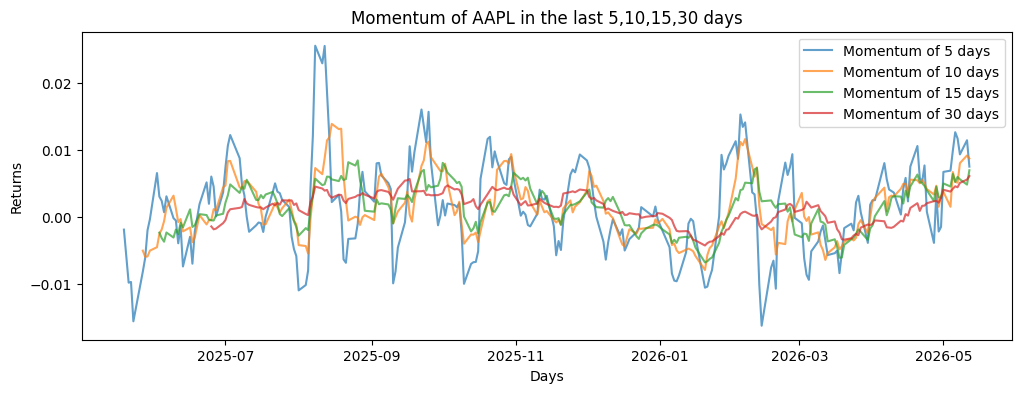

In [32]:
plt.figure(figsize=(12,4))
plt.plot(history['Momentum_5days'],label = 'Momentum of 5 days',alpha = 0.7)
plt.plot(history['Momentum_10days'],label = 'Momentum of 10 days',alpha = 0.7)
plt.plot(history['Momentum_15days'],label = 'Momentum of 15 days',alpha = 0.7)
plt.plot(history['Momentum_30days'],label = 'Momentum of 30 days',alpha = 0.7)
plt.title('Momentum of AAPL in the last 5,10,15,30 days')
plt.xlabel('Days')
plt.ylabel('Returns')
plt.legend()
plt.show()

## SMA Ratio

**SMA Ratio** measures where the current price sits relative to its 30-day moving average:

$$\text{SMA Ratio}_t = \frac{\text{Close}_t}{\text{SMA30}_t}$$

- **SMA Ratio > 1** → price is above its 30-day average → stock is in an uptrend
- **SMA Ratio < 1** → price is below its 30-day average → stock is in a downtrend
- **SMA Ratio = 1** → price is exactly at its average

**Why it is useful:**
- Raw price is non-stationary and hard for a model to interpret across time
- The ratio normalizes price into a relative measure — telling the model not that the price is $294 but that it is 8.8% above its recent trend
- This makes it a consistent signal regardless of the price level or time period

**Note:** After inspecting the feature weights from the linear regression model, SMA Ratio had a weight of -0.01 — near zero — meaning it contributed almost no predictive power. It was dropped from the final feature set to reduce overfitting.

In [33]:
#SMA ratio - closing price relative to 30-day moving average
history['SMA_Ratio'] = history['Close'] / sma_30

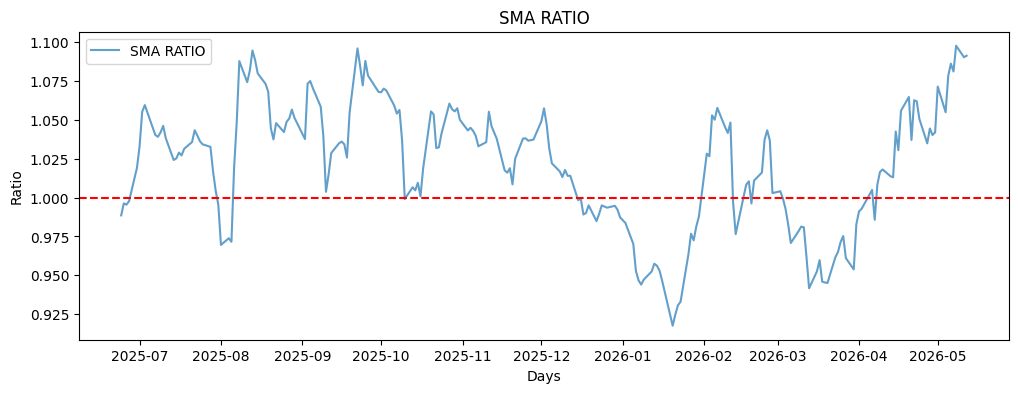

In [34]:
plt.figure(figsize=(12,4))
plt.plot(history['SMA_Ratio'], label = 'SMA RATIO', alpha = 0.7)
plt.xlabel('Days')
plt.ylabel('Ratio')
plt.title('SMA RATIO')
plt.axhline(y=1,color='red',linestyle = '--')
plt.legend()
plt.show()

In [35]:
#drop NaN rows and save back to history, then split into X (features) and y (target)
feature_cols = ['Lag1', 'Lag2', 'Lag3',
                'Vol_5day', 'Vol_30day',
                'Momentum_5days', 'Momentum_30days']

history = history[['Close', 'Return'] + feature_cols].dropna()

X = history[feature_cols].values
y = history['Return'].values

In [36]:
#Train/test split 80/20 split
split = int(len(X)*0.8)
X_train, X_test = X[:split],X[split:]
y_train, y_test = y[:split],y[split:]

#fitting model into my linear regression
theta = linear_regression(X_train,y_train)

#Time to predict 
X_test_b = np.c_[np.ones((len(X_test),1)),X_test]
y_pred = X_test_b @ theta


## Reading the Visualizations

---

### 1. Returns Over Time

The y-axis is the daily return as a decimal — `0.02` = 2% gain, `-0.03` = 3% loss. You are looking for:
- How volatile the stock is (how tall the spikes are)
- Any clustering of big moves (volatility tends to cluster together)
- General pattern of ups and downs over the year

---

### 2. Lag Correlation Scatter Plots

Each dot is one trading day. The x-axis is the lagged return (e.g. yesterday's return) and the y-axis is today's return — both in decimal form.

You are looking for a pattern in the dots:
- **Diagonal trend (up-right / down-left)** → past returns predict future returns (momentum)
- **No pattern, random cloud** → past returns have no predictive power
- The more scattered the dots, the weaker the relationship

---

### 3. Correlation Heatmap

The numbers range from $-1$ to $1$:
- $1.0$ → perfect positive correlation (move together)
- $-1.0$ → perfect negative correlation (move opposite)
- $0.0$ → no relationship at all

For stock returns you would typically see values very close to $0$ between lags and today's return. This is consistent with the **Efficient Market Hypothesis (EMH)**, which states that prices already reflect all available information — so past returns should not strongly predict future ones.

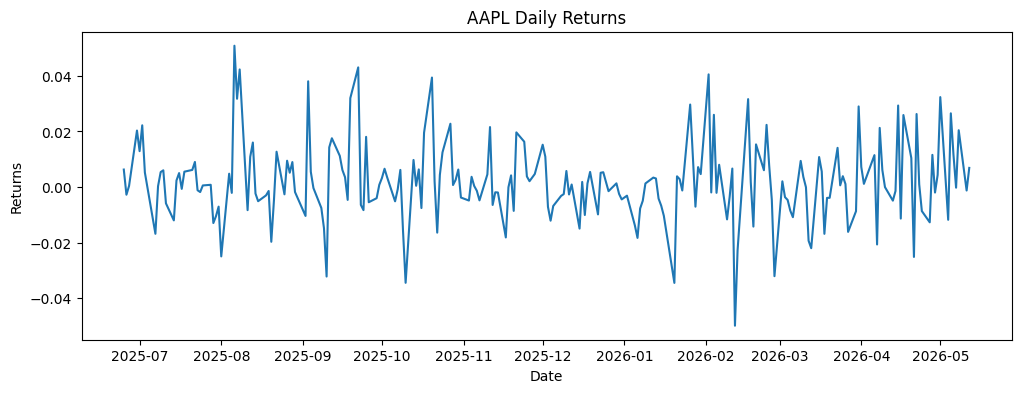

In [37]:
#Returns over time
plt.figure(figsize=(12,4))
plt.plot(history.index, history['Return'])
plt.title('AAPL Daily Returns')
plt.xlabel('Date')
plt.ylabel('Returns')
plt.show()

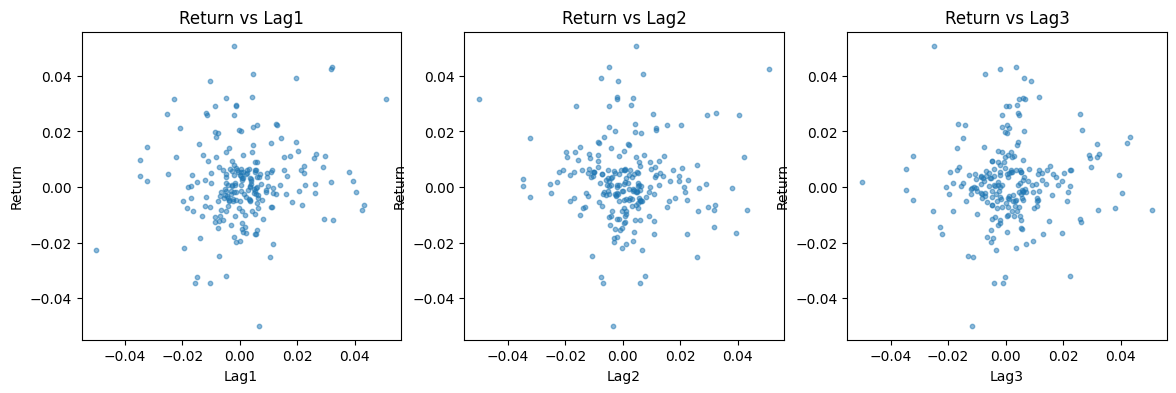

In [38]:
#Lag correlation scatter plot
fig, axes = plt.subplots(1,3,figsize=(14,4))

for i, lag in enumerate(['Lag1', 'Lag2', 'Lag3']):
    axes[i].scatter(history[lag], history['Return'], alpha=0.5, s=10)
    axes[i].set_xlabel(lag)
    axes[i].set_ylabel('Return')
    axes[i].set_title(f'Return vs {lag}')

plt.tight_layout
plt.show()

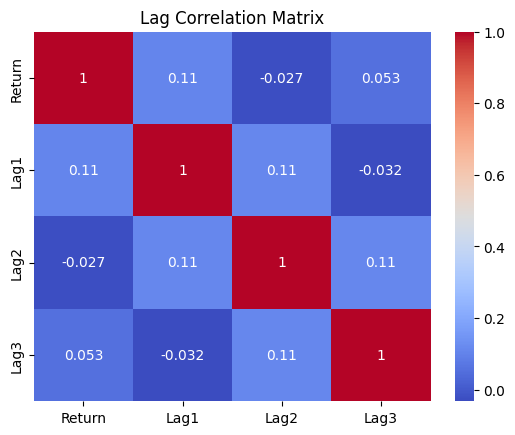

In [39]:
#correlation heatmap
corr = history[['Return','Lag1','Lag2','Lag3']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Lag Correlation Matrix')
plt.show()

In [40]:
#mean square error to average squared difference between predicted and actual returns
mse = np.mean((y_test - y_pred)**2)
print(f'MSE: {mse:.6f}')

MSE: 0.000145


In [41]:
#R^2 how much variance my model explains, from 0 to 1 the higher the better and if negative it is worse than just pred the mean
ss_res = np.sum((y_test - y_pred) ** 2)
ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)
r2 = 1 - (ss_res / ss_tot)
print(f'R²: {r2:.4f}')


R²: 0.3092


In [42]:
for name, weight in zip(feature_cols, theta[1:]):
    print(f'{name}: {weight:.6f}')


Lag1: -0.418704
Lag2: -0.498672
Lag3: -0.582546
Vol_5day: 0.298715
Vol_30day: -0.417566
Momentum_5days: 2.420970
Momentum_30days: 0.432776


In [43]:
X_train_b = np.c_[np.ones((len(X_train), 1)), X_train]
y_pred_train = X_train_b @ theta
ss_res_train = np.sum((y_train - y_pred_train) ** 2)
ss_tot_train = np.sum((y_train - np.mean(y_train)) ** 2)
r2_train = 1 - (ss_res_train / ss_tot_train)
print(f'Train R²: {r2_train:.4f}')
print(f'Test R²:  {r2:.4f}')


Train R²: 0.5256
Test R²:  0.3092


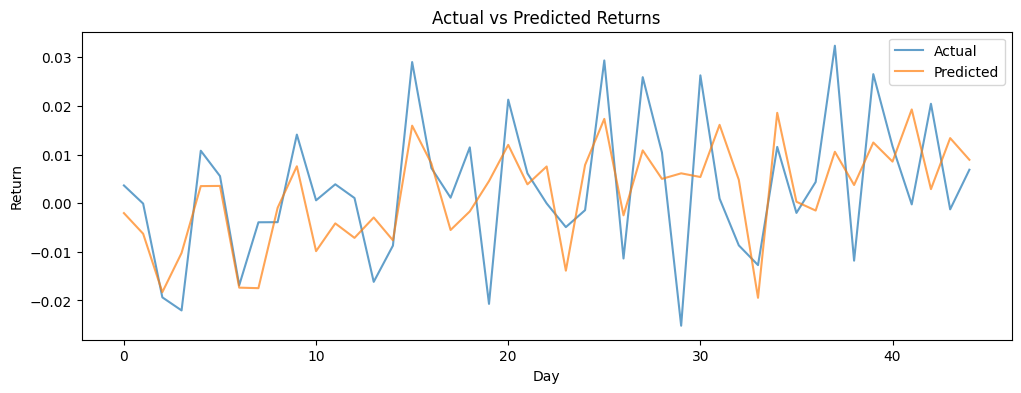

In [44]:
plt.figure(figsize=(12, 4))
plt.plot(y_test, label='Actual', alpha=0.7)
plt.plot(y_pred, label='Predicted', alpha=0.7)
plt.title('Actual vs Predicted Returns')
plt.xlabel('Day')
plt.ylabel('Return')
plt.legend()
plt.show()


## Conclusions — Linear Regression Baseline

---

### What I Learned

- **Lagged returns alone are weak predictors.** Starting with only Lag1, Lag2, Lag3 gave a test R² of -0.09, meaning the model was worse than just predicting the mean return every day. This is consistent with the Efficient Market Hypothesis — past prices alone carry little information about future returns.

- **Feature engineering makes a significant difference.** Adding volatility and momentum features improved the test R² from -0.09 to 0.31. The model performs much better when it can see not just what the return was yesterday, but how volatile and directional the stock has been recently.

- **More features does not always mean a better model.** Starting with 12 features caused notable overfitting — train R² of 0.55 vs test R² of 0.30. Printing the learned weights revealed which features were contributing and which were not.

- **SMA Ratio added no value.** Its learned weight was -0.01, near zero, meaning the model ignored it. It was dropped to reduce noise.

- **Mean reversion signal.** The lag weights were all negative, meaning the model learned that a positive return yesterday slightly predicts a negative return today — a mean reversion pattern.

- **Momentum_5days was the strongest feature** with a weight of 2.42, showing that short-term trend direction is the most informative signal in this feature set.

---

### Why Switch to Random Forest

Linear regression assumes a straight-line relationship between features and returns. In reality, market relationships are non-linear — for example, high volatility combined with strong momentum might behave very differently than high volatility alone. Linear regression cannot capture these interactions.

Random Forest handles non-linear relationships naturally through decision trees, and has built-in mechanisms like `max_depth` to control overfitting — giving more tools to close the gap between train and test R².

## Random Forest — From Scratch Implementation

A Random Forest is an ensemble of Decision Trees, each trained on a different random bootstrap sample of the data. The final prediction is the average across all trees — averaging reduces variance and helps the model generalize better than any single tree.

Three classes are needed to build it from scratch:

**Node** — the building block of a decision tree. Each node stores:
- `feature` — which feature column to split on
- `threshold` — the value to split at (rows <= threshold go left, rows > threshold go right)
- `left` / `right` — child nodes
- `value` — only set on leaf nodes, stores the mean of the target values that landed here

**DecisionTree** — grows a single tree by recursively finding the best split at each node:
- `_best_split` loops over a random subset of features and all unique threshold values, picking the split that minimises weighted MSE
- `_weighted_mse` = (len(left) * var(left) + len(right) * var(right)) / n — lower is better
- `_grow` recurses until `max_depth` is hit or a node has fewer than `min_samples_split` rows
- `_traverse` walks a single row from root to leaf to produce a prediction

**RandomForest** — wraps a list of trees:
- `fit` creates bootstrap samples (random rows **with** replacement), trains one `DecisionTree` on each, and appends it to `self.trees`
- `predict` averages the predictions from all trees — the averaging is what reduces variance
- Each tree only sees `int(sqrt(n_features))` randomly chosen features per split, which keeps trees decorrelated from each other

In [61]:
#personal implementation of Random Forest from Scratch 
#3 things I need to implment 
#Node, DecisionTree, RandomForest

class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value
    
class DecisionTree:
    def __init__(self, max_depth=None, min_samples_split=None, n_features=None):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.n_features = n_features
        self.root = None

    def fit(self, X, y):
        if (self.n_features is None):
            self.n_features = X.shape[1]
        self.root = self._grow(X,y, depth=0)

    def _grow(self, X, y, depth):
        if (depth>=self.max_depth or X.shape[0]<self.min_samples_split):
            return Node(value=np.mean(y))
        
        randomFeatures = np.random.choice(X.shape[1],self.n_features, replace=False)

        bestFeat, bestThresh = self._best_split(X, y, randomFeatures)

        if bestFeat is None:
            return Node(value=np.mean(y))
        
        leftMask = X[:,bestFeat]<= bestThresh
        left = self._grow(X[leftMask],y[leftMask], depth + 1)
        right = self._grow(X[~leftMask],y[~leftMask], depth + 1)

        return Node(feature=bestFeat, threshold=bestThresh, left=left, right=right)
    
    def _best_split(self, X, y, randomFeatures):
        bestScore = float('inf')
        bestFeat,bestThresh = None, None
        for i in randomFeatures:
            for j in np.unique(X[:, i]):
                mask = X[:, i]<=j
                left = y[mask]
                right = y[~mask]
                if (len(left)==0 or len(right) == 0): continue 
                score = self._weighted_mse(left,right)
                if score < bestScore:
                    bestScore = score
                    bestFeat = i
                    bestThresh = j
        return bestFeat,bestThresh

    def _weighted_mse(self,left_y, right_y):
        n = len(left_y) + len(right_y)
        return (len(left_y)*np.var(left_y)+len(right_y)*np.var(right_y)) / n
    
    def _traverse(self, x, node):
        if node.value is not None:
            return node.value
        if x[node.feature] <= node.threshold:
            return self._traverse(x , node.left)
        return self._traverse(x, node.right)

    def predict(self, X):
        return np.array([self._traverse(x, self.root) for x in X])




class RandomForest:
    def __init__(self, n_estimator=None, max_depth=None, min_samples_split=None):
        self.n_estimator = n_estimator
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.trees = []

    def fit(self, X, y):
        for _ in range(self.n_estimator):
            idxs = np.random.choice(len(X),len(y), replace=True)
            X_sample, y_sample = X[idxs], y[idxs]
            tree = DecisionTree(max_depth=self.max_depth, min_samples_split=self.min_samples_split, n_features=int(np.sqrt(X.shape[1])))
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)
    
    def predict(self, X):
        return np.mean([tree.predict(X) for tree in self.trees], axis=0)




In [82]:
rf = RandomForest(n_estimator=100, max_depth=5, min_samples_split=5)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_pred_rf_train = rf.predict(X_train)

mse_rf = np.mean((y_test - y_pred_rf)**2)

ss_res_rf = np.sum((y_test - y_pred_rf)**2)
ss_tot_rf = np.sum((y_test - np.mean(y_test))**2)
r2_rf = 1 - (ss_res_rf / ss_tot_rf)

ss_res_train = np.sum((y_train - y_pred_rf_train)**2)
ss_tot_train = np.sum((y_train - np.mean(y_train))**2)
r2_train_rf = 1 - (ss_res_train / ss_tot_train)


print(f'MSE: {mse_rf:.6f}')
print(f'Test R^2: {r2_rf:.4f}')
print(f'Train R^2 {r2_train_rf:.4f}')



MSE: 0.000191
Test R^2: 0.0920
Train R^2 0.6242


## Hyperparameter Tuning — Grid Search

The from-scratch Random Forest has two key hyperparameters that control how complex each tree can grow:

- **`max_depth`** — limits how deep each tree can go. A deeper tree memorises the training data more precisely (higher train R²) but generalises poorly to new data (lower test R²). Shallower trees are more conservative.
- **`min_samples_split`** — the minimum number of rows a node must have before it is allowed to split further. Higher values force the tree to stop splitting sooner, reducing overfitting.

Choosing these by hand is guesswork. Grid search solves this by training a model for every combination of candidate values and picking the one that performs best on a held-out validation set.

**Why a separate validation set?**
If you pick hyperparameters that maximise test R², you are effectively fitting to the test set — and your final reported score is no longer an honest estimate of out-of-sample performance. The correct approach is:
1. Split training data further into a train portion and a validation portion (chronologically, since this is time series)
2. Use validation R² to select the best hyperparameters
3. Retrain on the full training set with those parameters
4. Evaluate once on the test set

The grid searches over `max_depth` in [2, 3, 4, 5, 6] and `min_samples_split` in [5, 10, 20, 30, 50] — 25 combinations total.

In [79]:
from itertools import product

max_depths = [2, 3, 4, 5, 6]
min_samples = [5, 10, 20, 30, 50]

val_split = int(len(X_train) * 0.8)
X_tr, X_val = X_train[:val_split], X_train[val_split:]
y_tr, y_val = y_train[:val_split], y_train[val_split:]

best_r2 = -np.inf
best_params = None

for depth, samples in product(max_depths, min_samples):
    rf_tmp = RandomForest(n_estimator=100, max_depth=depth, min_samples_split=samples)
    rf_tmp.fit(X_tr, y_tr)
    y_val_pred = rf_tmp.predict(X_val)
    ss_res = np.sum((y_val - y_val_pred)**2)
    ss_tot = np.sum((y_val - np.mean(y_val))**2)
    r2 = 1 - (ss_res / ss_tot)
    if r2 > best_r2:
        best_r2 = r2
        best_params = (depth, samples)

print(f'Best params: max_depth={best_params[0]}, min_samples_split={best_params[1]}')
print(f'Best validation R²: {best_r2:.4f}')

# retrain on full training set with best params
rf_best = RandomForest(n_estimator=100, max_depth=best_params[0], min_samples_split=best_params[1])
rf_best.fit(X_train, y_train)

y_pred_best = rf_best.predict(X_test)
y_pred_best_train = rf_best.predict(X_train)

ss_res_best = np.sum((y_test - y_pred_best)**2)
ss_tot_best = np.sum((y_test - np.mean(y_test))**2)
r2_best = 1 - (ss_res_best / ss_tot_best)
mse_best = np.mean((y_test - y_pred_best)**2)

ss_res_best_train = np.sum((y_train - y_pred_best_train)**2)
ss_tot_best_train = np.sum((y_train - np.mean(y_train))**2)
r2_best_train = 1 - (ss_res_best_train / ss_tot_best_train)

print(f'\nFinal Train R²: {r2_best_train:.4f}')
print(f'Final Test R²:  {r2_best:.4f}')
print(f'Final Test MSE: {mse_best:.6f}')


Best params: max_depth=5, min_samples_split=10
Best validation R²: 0.2310

Final Train R²: 0.5915
Final Test R²:  0.0861
Final Test MSE: 0.000192


In [81]:
from sklearn.ensemble import RandomForestRegressor
rf_sk = RandomForestRegressor(n_estimators=100, max_depth=5, min_samples_split=5, random_state=42)
rf_sk.fit(X_train, y_train)

y_pred_sk = rf_sk.predict(X_test)
y_pred_sk_train = rf_sk.predict(X_train)

mse_sk = np.mean((y_test - y_pred_sk)**2)

ss_res_sk = np.sum((y_test - y_pred_sk)**2)
ss_tot_sk = np.sum((y_test - np.mean(y_test))**2)
r2_sk = 1 - (ss_res_sk / ss_tot_sk)

ss_res_sk_train = np.sum((y_train - y_pred_sk_train)**2)
ss_tot_sk_train = np.sum((y_train - np.mean(y_train))**2)
r2_sk_train = 1 - (ss_res_sk_train / ss_tot_sk_train)

print(f'Train R²: {r2_sk_train:.4f}')
print(f'Test R²:  {r2_sk:.4f}')
print(f'MSE:      {mse_sk:.6f}')

Train R²: 0.6747
Test R²:  0.1468
MSE:      0.000180


## sklearn RandomForestRegressor — Comparison

After building Random Forest from scratch, it is useful to compare against sklearn's implementation to understand how much of the performance gap is due to implementation quality vs the dataset itself.

sklearn's `RandomForestRegressor` differs from the from-scratch version in several ways:
- Uses optimised C-level code internally — much faster and more numerically stable
- Considers the full set of unique thresholds more efficiently
- Uses slightly different default splitting logic and aggregation

The same hyperparameters (`n_estimators=100`, `max_depth=5`, `min_samples_split=5`) are used so the comparison is fair. `random_state=42` is set to make results reproducible.

## Conclusions — Random Forest

---

### Results Summary

| Model | MSE | Test R² | Train R² |
|-------|-----|---------|---------|
| Linear Regression | 0.000145 | 0.3092 | 0.5256 |
| RF from scratch (grid search) | 0.000192 | 0.0861 | 0.5915 |
| sklearn RandomForest | 0.000180 | 0.1468 | 0.6747 |

---

### What I Learned

- **Random Forest did not beat linear regression on this dataset.** Despite being a more powerful model in theory, all RF variants scored lower on test R² than the linear regression baseline. This is a real finding — on small datasets (~220 rows), simpler models often generalise better because there is not enough data for trees to find reliable, stable splits.

- **sklearn RF outperformed the from-scratch RF.** The sklearn implementation achieves a higher test R² (0.1468 vs 0.0861) and better MSE using the same hyperparameters. This gap comes from sklearn's more optimised internal splitting logic, not from using a fundamentally different algorithm.

- **Random Forest overfits more than linear regression.** The train/test gap for sklearn RF is 0.53 points (0.67 train vs 0.15 test), compared to only 0.22 points for linear regression. More model complexity on a small dataset amplifies overfitting.

- **Grid search found the best hyperparameters honestly.** By tuning on a validation set carved out of the training data — not the test set — the reported test R² is a genuine out-of-sample score, not one inflated by peeking at the test data.

- **The bottleneck is the dataset, not the model.** Both RF implementations struggle for the same reason: 220 rows is not enough data for trees to discover non-linear patterns that generalise. A larger dataset (e.g. multiple stocks or a longer history) would likely close this gap.

---

### What Is Next — XGBoost

XGBoost (Gradient Boosted Trees) builds trees **sequentially** rather than in parallel like Random Forest. Each new tree corrects the residual errors of the previous one, allowing the model to progressively focus on the hardest-to-predict samples.

Key differences from Random Forest that may help on this small dataset:
- **Learning rate** (`eta`) controls how much each tree contributes — smaller values reduce overfitting
- **Subsampling** of rows and columns per tree adds regularisation similar to RF's bootstrap
- **Built-in L1/L2 regularisation** (`reg_alpha`, `reg_lambda`) directly penalises model complexity

The goal is to see whether gradient boosting's more targeted learning strategy can close the gap with linear regression — or surpass it.